In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")


All libraries imported!


In [2]:
df = pd.read_csv('credit_risk_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,0,123.0,0,4,35000,16.02,1,0.59,1,3
1,21,9600,1,5.0,1,2,1000,11.14,0,0.10,0,2
2,25,9600,2,1.0,2,3,5500,12.87,1,0.57,0,3
3,23,65500,0,4.0,2,3,35000,15.23,1,0.53,0,2
4,24,54400,0,8.0,2,3,35000,14.27,1,0.55,1,4


In [3]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print("Features:", X.shape)
print("Target:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features: (32581, 11)
Target: (32581,)

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()

num_cols = ['person_age', 'person_income', 'person_emp_length', 
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
            'cb_person_cred_hist_length']

X[num_cols] = scaler.fit_transform(X[num_cols])

# Save scaler for dashboard later
joblib.dump(scaler, 'credit_scaler.pkl')
print("Scaling done & scaler saved!")

Scaling done & scaler saved!


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (26064, 11)
Testing set: (6517, 11)


In [6]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
loan_status
0    20378
1     5686
Name: count, dtype: int64

After SMOTE:
loan_status
0    20378
1    20378
Name: count, dtype: int64


In [7]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)
print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non Default', 'Default']))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

 Non Default       0.93      0.99      0.96      5095
     Default       0.96      0.73      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517

ROC-AUC Score: 0.941867388810905


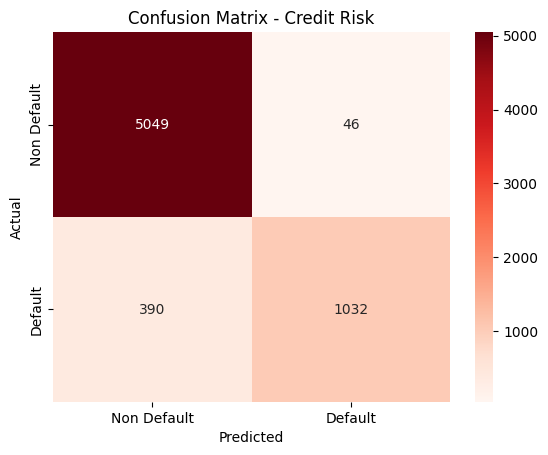

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non Default', 'Default'],
            yticklabels=['Non Default', 'Default'])
plt.title('Confusion Matrix - Credit Risk')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [10]:
# Convert probability to risk score
df_test = X_test.copy()
df_test['default_probability'] = y_prob
df_test['risk_score'] = (y_prob * 100).round(2)

# Categorize risk
def categorize_risk(score):
    if score < 30:
        return 'Low Risk 🟢'
    elif score < 60:
        return 'Medium Risk 🟡'
    else:
        return 'High Risk 🔴'

df_test['risk_category'] = df_test['risk_score'].apply(categorize_risk)

print(df_test[['risk_score', 'risk_category']].head(10))

       risk_score  risk_category
6616     5.570000     Low Risk 🟢
21802    4.920000     Low Risk 🟢
31886    4.560000     Low Risk 🟢
17799    7.920000     Low Risk 🟢
5207     3.730000     Low Risk 🟢
2543    23.459999     Low Risk 🟢
14816    7.510000     Low Risk 🟢
10276    4.570000     Low Risk 🟢
26929    8.510000     Low Risk 🟢
22964   40.750000  Medium Risk 🟡


In [11]:
joblib.dump(model, 'credit_risk_model.pkl')
print("Credit Risk Model saved successfully!")

Credit Risk Model saved successfully!


In [12]:
import joblib
joblib.dump(model, r'P:\Financial Risk Intelligence Platform\models\credit_risk_model.pkl')
joblib.dump(scaler, r'P:\Financial Risk Intelligence Platform\models\credit_scaler.pkl')
print("All models re-saved successfully!")

All models re-saved successfully!
